<a href="https://colab.research.google.com/github/kimve1969/mgu_ds_cours/blob/main/semestr%202.2/task%201/bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import requests

response = requests.get('https://disk.yandex.ru/d/LkS7sYt8m0MtvQ')

# Сохраняем файл
with open("bank-full.csv", "wb") as file:
    file.write(response.content)

In [22]:
import pandas as pd

try:
    # Исправляем загрузку CSV, указывая разделитель ";"
    df_csv = pd.read_csv('bank-full.csv', sep=';')
    print("Первые 5 строк CSV-файла:")
    print(df_csv.head())
except FileNotFoundError:
    print("CSV-файл 'bank-full.csv' не найден. Убедитесь, что файл загружен и имя указано верно.")

Первые 5 строк CSV-файла:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [23]:
print("\nИнформация о DataFrame:")
df_csv.info()

print("\nПроверка на пропущенные значения:")
print(df_csv.isnull().sum())

print("\nОписательная статистика для числовых столбцов:")
print(df_csv.describe())

print("\nКоличество уникальных значений для некоторых категориальных столбцов:")
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']:
    if col in df_csv.columns:
        print(f"\n{col}:")
        print(df_csv[col].value_counts())


Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Проверка на пропущенные значения:
age          0
job          0
marital  

Построение pairplot для ключевых параметров...


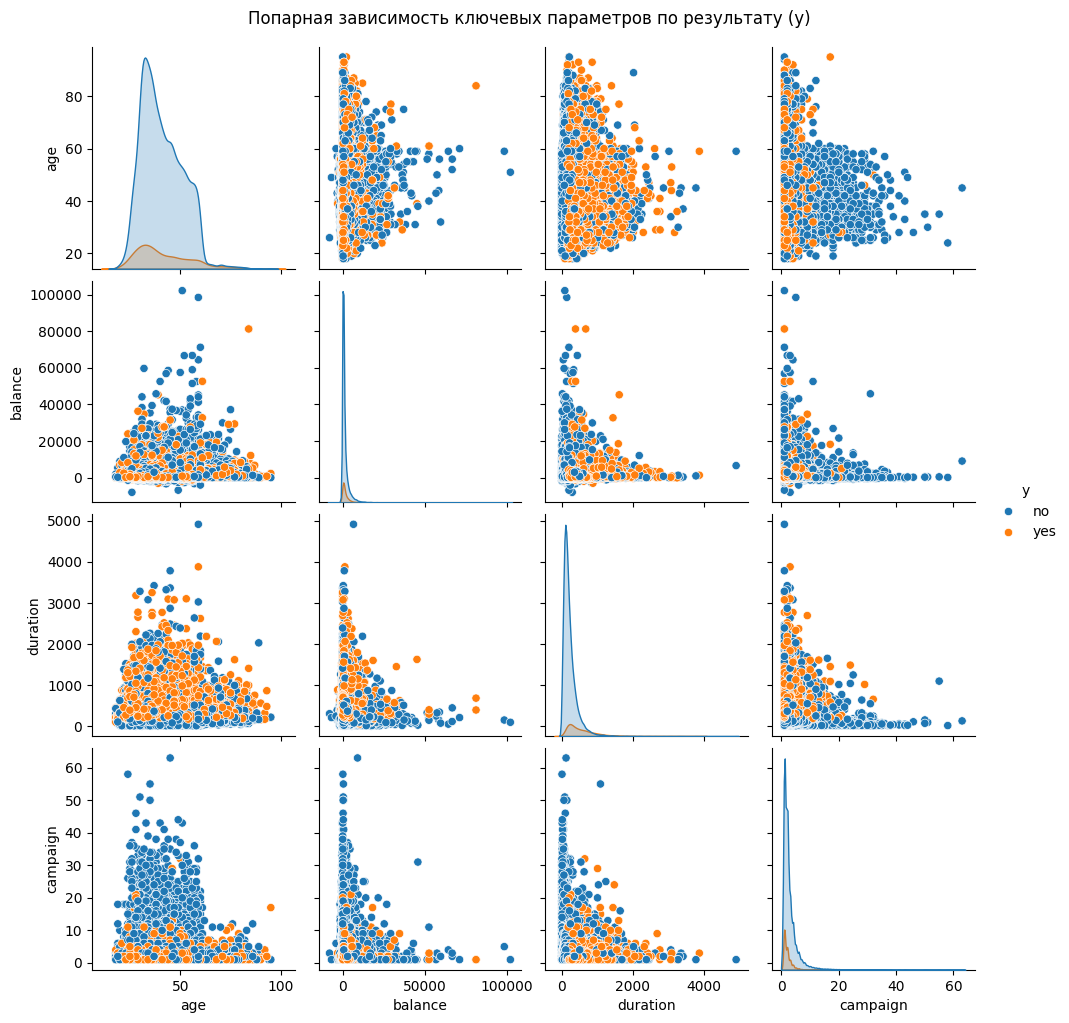

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Выбираем несколько ключевых числовых столбцов и целевую переменную 'y'
selected_columns = ['age', 'balance', 'duration', 'campaign', 'y']

# Строим pairplot для выбранных столбцов, используя 'y' для цветовой индикации
# Чтобы избежать проблем с производительностью на больших наборах данных, можно рассмотреть выборку (sample)
# или ограничиться меньшим количеством столбцов.
# Для данного датасета pairplot должен отработать нормально.

print("Построение pairplot для ключевых параметров...")

sns.pairplot(df_csv[selected_columns], diag_kind='kde', hue='y')
plt.suptitle('Попарная зависимость ключевых параметров по результату (y)', y=1.02) # Общий заголовок для графиков
plt.show()

In [25]:
# Выбираем только числовые столбцы для расчета матрицы корреляции
numerical_cols = df_csv.select_dtypes(include=['int64', 'float64']).columns

print("\nМатрица корреляции для числовых столбцов:")
correlation_matrix = df_csv[numerical_cols].corr()
display(correlation_matrix)

# Для лучшей визуализации можно также построить тепловую карту корреляции
# import matplotlib.pyplot as plt
# import seaborn as sns
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Тепловая карта матрицы корреляции')
# plt.show()


Матрица корреляции для числовых столбцов:


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


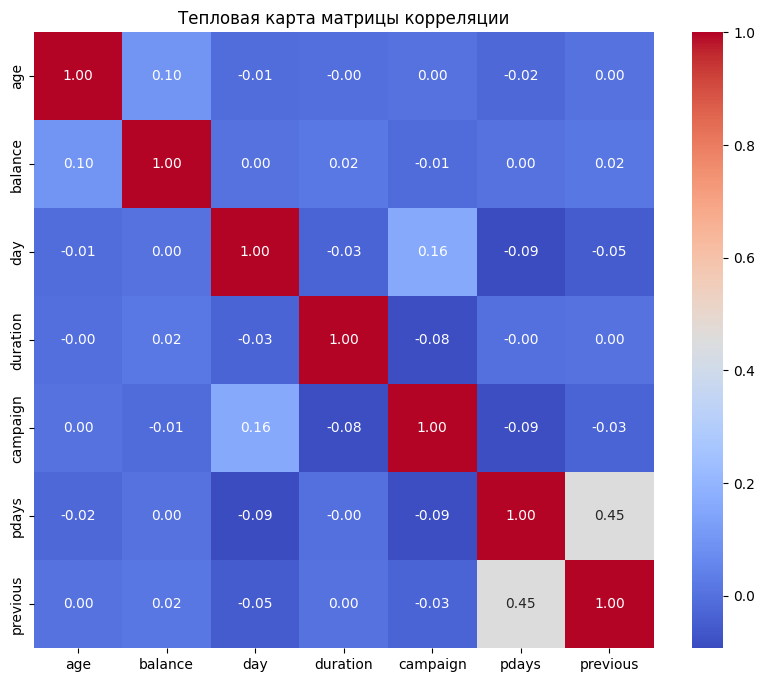

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта матрицы корреляции')
plt.show()

### Подготовка данных для моделирования

In [30]:
# Разделение признаков (X) и целевой переменной (y)
X = df_csv.drop('y', axis=1)
y = df_csv['y']

# Кодирование целевой переменной 'y' (yes/no в 1/0)
y = y.map({'yes': 1, 'no': 0})

print("Размерность df_csv:", df_csv.shape)
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

Размерность df_csv: (45211, 17)
Размерность X: (45211, 16)
Размерность y: (45211,)


### One-Hot Encoding для категориальных признаков

In [31]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Размерность X после One-Hot Encoding:", X_encoded.shape)
display(X_encoded.head())

Размерность X после One-Hot Encoding: (45211, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


### Разделение данных на обучающую и тестовую выборки

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print("Размерность обучающей выборки X_train:", X_train.shape)
print("Размерность тестовой выборки X_test:", X_test.shape)
print("Размерность обучающей выборки y_train:", y_train.shape)
print("Размерность тестовой выборки y_test:", y_test.shape)

print("\nРаспределение целевой переменной в обучающей выборке:\n", y_train.value_counts(normalize=True))
print("\nРаспределение целевой переменной в тестовой выборке:\n", y_test.value_counts(normalize=True))

Размерность обучающей выборки X_train: (31647, 42)
Размерность тестовой выборки X_test: (13564, 42)
Размерность обучающей выборки y_train: (31647,)
Размерность тестовой выборки y_test: (13564,)

Распределение целевой переменной в обучающей выборке:
 y
0    0.883022
1    0.116978
Name: proportion, dtype: float64

Распределение целевой переменной в тестовой выборке:
 y
0    0.882999
1    0.117001
Name: proportion, dtype: float64


### Построение и обучение модели логистической регрессии

In [33]:
from sklearn.linear_model import LogisticRegression

# Инициализация модели логистической регрессии
# Устанавливаем max_iter, так как датасет большой
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=500)

# Обучение модели
model.fit(X_train, y_train)

print("Модель логистической регрессии успешно обучена.")

Модель логистической регрессии успешно обучена.


### Оценка производительности модели

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Прогнозы на тестовой выборке
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Расчет метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица ошибок:\n", conf_matrix)

# Отчет по классификации
class_report = classification_report(y_test, y_pred)
print("\nОтчет по классификации:\n", class_report)

Accuracy: 0.9025
Precision: 0.6576
Recall: 0.3485
F1-Score: 0.4555
ROC AUC: 0.9046

Матрица ошибок:
 [[11689   288]
 [ 1034   553]]

Отчет по классификации:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     11977
           1       0.66      0.35      0.46      1587

    accuracy                           0.90     13564
   macro avg       0.79      0.66      0.70     13564
weighted avg       0.89      0.90      0.89     13564



### Обучение и сравнение дополнительных моделей

In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import pandas as pd

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Матрица ошибок:\n", confusion_matrix(y_test, y_pred))
    print("Отчет по классификации:\n", classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

In [38]:
# Инициализация моделей
lda_model = LinearDiscriminantAnalysis()
qda_model = QuadraticDiscriminantAnalysis()
knn_model = KNeighborsClassifier(n_neighbors=5) # Можно настроить n_neighbors
gnb_model = GaussianNB()

# Список для хранения результатов
results = []

# Оценка логистической регрессии (уже обучена)
logreg_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, model.predict(X_test)),
    'Precision': precision_score(y_test, model.predict(X_test)),
    'Recall': recall_score(y_test, model.predict(X_test)),
    'F1-Score': f1_score(y_test, model.predict(X_test)),
    'ROC AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
}
results.append(logreg_metrics)

# Оценка других моделей
results.append(evaluate_model(lda_model, X_train, y_train, X_test, y_test, 'Linear Discriminant Analysis'))
results.append(evaluate_model(qda_model, X_train, y_train, X_test, y_test, 'Quadratic Discriminant Analysis'))
results.append(evaluate_model(knn_model, X_train, y_train, X_test, y_test, 'KNeighbors Classifier'))
results.append(evaluate_model(gnb_model, X_train, y_train, X_test, y_test, 'Gaussian Naive Bayes'))

# Создание DataFrame для сравнения
results_df = pd.DataFrame(results)
display(results_df.set_index('Model'))


--- Linear Discriminant Analysis ---
Accuracy: 0.9014
Precision: 0.6111
Recall: 0.4316
F1-Score: 0.5059
ROC AUC: 0.9039
Матрица ошибок:
 [[11541   436]
 [  902   685]]
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95     11977
           1       0.61      0.43      0.51      1587

    accuracy                           0.90     13564
   macro avg       0.77      0.70      0.73     13564
weighted avg       0.89      0.90      0.89     13564


--- Quadratic Discriminant Analysis ---
Accuracy: 0.8694
Precision: 0.4471
Recall: 0.4896
F1-Score: 0.4674
ROC AUC: 0.8424
Матрица ошибок:
 [[11016   961]
 [  810   777]]
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93     11977
           1       0.45      0.49      0.47      1587

    accuracy                           0.87     13564
   macro avg       0.69      0.70      0.70     13564
weighted a

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Accuracy: 0.8802
Precision: 0.4793
Recall: 0.2766
F1-Score: 0.3508
ROC AUC: 0.7591
Матрица ошибок:
 [[11500   477]
 [ 1148   439]]
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93     11977
           1       0.48      0.28      0.35      1587

    accuracy                           0.88     13564
   macro avg       0.69      0.62      0.64     13564
weighted avg       0.86      0.88      0.87     13564


--- Gaussian Naive Bayes ---
Accuracy: 0.8637
Precision: 0.4299
Recall: 0.5066
F1-Score: 0.4651
ROC AUC: 0.8200
Матрица ошибок:
 [[10911  1066]
 [  783   804]]
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92     11977
           1       0.43      0.51      0.47      1587

    accuracy                           0.86     13564
   macro avg       0.68      0.71      0.69     13564
weighted avg       0.87      0.86      0.87     13564



,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.902536,0.657551,0.348456,0.455519,0.904608
Linear Discriminant Analysis,0.901357,0.611062,0.431632,0.505908,0.903854
Quadratic Discriminant Analysis,0.869434,0.447066,0.489603,0.467368,0.842388
KNeighbors Classifier,0.880198,0.479258,0.276623,0.350779,0.759104
Gaussian Naive Bayes,0.863683,0.429947,0.506616,0.465143,0.819954
